# 금천구 무더위쉼터 최적 입지 분석 (수정본)

`GeumcheonHeatShelterLocation.ipynb`를 고친 버전이다. 원본은 그대로 두었다.

## 원본에서 고친 것

| 문제 | 원본 결과에 준 영향 | 수정 |
|---|---|---|
| 수요지를 금천구로 자르지 않음 | 수도권 82만 격자, 인구 2,522만 명이 금천구 경계 노드로 몰림. 스냅 거리 평균 28km. 커버율 14.6%는 이 때문 | 행정동 경계 안의 격자만 사용 |
| 후보지에 이미 쉼터인 시설이 섞인 파일 사용 | 같은 노드에 붙은 경우만 걸러져 일부가 신규 후보로 남을 수 있음 | 기존 쉼터를 뺀 46곳 파일 사용 |
| 기준거리 300m | 설계서 기본값 400m, 민감도 250/600m와 다름 | 400m 기본, 250/400/600m 민감도 |
| 경로가 다른 PC 기준 | 이 PC에서 실행 불가 | 노트북 폴더 기준 상대경로 |
| 행정동 shp에 .shx .dbf .prj 없음 | 읽기 실패 | .shx 복원, 좌표계 5179 지정. 동 이름은 .dbf가 있어야 나옴 |

추가한 것은 최대 접근거리와 상위 5% 평균거리 지표, 두 모형의 공통 선정지 표, 시설 수 민감도다.

## 이 노트북의 수요 자료는 연습용이다

`Geumcheon_Test_Population_with_Coordinates.csv`는 2023년 100m 격자 총인구다. 60대 이상도 아니고 유동인구도 아니다. 파이프라인이 끝까지 도는지 확인하는 용도이며, 여기서 나온 선정 입지는 결과로 쓰면 안 된다. 안심구역에서 50m 격자 유동인구로 `DEMAND_PATH`와 `WEIGHT_COL`만 바꾸면 같은 흐름으로 실제 결과가 나온다.

## 0. 설정

In [1]:
import os
import warnings
from collections import defaultdict
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pulp
from matplotlib import font_manager
from scipy.spatial import cKDTree
from shapely import wkt
from shapely.geometry import Point

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

font_path = r"C:\Windows\Fonts\malgun.ttf"
if Path(font_path).exists():
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

# 노트북이 있는 DONGGEUN 폴더를 기준으로 한다.
BASE_DIR = Path.cwd()

NETWORK_PATH = BASE_DIR / "SeoulPedestrianNetwork.csv"
ADM_DONG_PATH = BASE_DIR / "GeumcheonAdministrativeDongBoundary.shp"
EXISTING_PATH = BASE_DIR / "GeumcheonCoolingCenter.csv"
CANDIDATE_PATH = BASE_DIR / "GeumcheonNewCandidates.csv"   # 기존 쉼터를 뺀 신규 후보 46곳
DEMAND_PATH = BASE_DIR / "Geumcheon_Test_Population_with_Coordinates.csv"  # 연습용

ANALYSIS_CRS = 5179
GEOGRAPHIC_CRS = 4326

P = 14
COVERAGE_DISTANCE_M = 400             # 설계서 3.4절 기본값
SENS_DISTANCES = [250, 400, 600]      # 설계서 9.2절
SENS_P = [5, 10, 14, 20, 25]

SNAP_CHECK_THRESHOLD_M = 100

LON_COL, LAT_COL = "경도", "위도"
WEIGHT_COL = "population"             # 안심구역에서 60대 이상 유동인구 컬럼으로 교체

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. 보조 함수

In [2]:
def read_point_csv(path, lon_col, lat_col):
    try:
        df = pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="cp949")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df = df.dropna(subset=[lon_col, lat_col]).copy()
    return gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[lon_col], df[lat_col]), crs=GEOGRAPHIC_CRS)


def snap_points_to_nodes(points_gdf, nodes_gdf):
    pts = points_gdf.to_crs(nodes_gdf.crs).copy()
    tree = cKDTree(np.column_stack([nodes_gdf.geometry.x, nodes_gdf.geometry.y]))
    dist, idx = tree.query(np.column_stack([pts.geometry.x, pts.geometry.y]), k=1)
    pts["network_node"] = nodes_gdf.iloc[idx]["node_id"].to_numpy()
    pts["snap_distance_m"] = dist
    return pts


def snap_summary(gdf, label, threshold=SNAP_CHECK_THRESHOLD_M):
    s = gdf["snap_distance_m"]
    print(f"[{label}] 평균 {s.mean():.1f}m, 최대 {s.max():.1f}m, {threshold}m 초과 {(s > threshold).sum()}개 / {len(s)}개")


def endpoint(geom, start=True):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type == "MultiLineString":
        geom = list(geom.geoms)[0 if start else -1]
    coords = list(geom.coords)
    return Point(coords[0] if start else coords[-1])


def weighted_mean(values, weights):
    values, weights = np.asarray(values, float), np.asarray(weights, float)
    m = np.isfinite(values) & (weights > 0)
    return np.average(values[m], weights=weights[m])


def weighted_coverage(covered, weights):
    covered, weights = np.asarray(covered, bool), np.asarray(weights, float)
    return weights[covered].sum() / weights.sum()


def weighted_top5_mean(values, weights):
    """수요 가중 기준으로 가장 먼 5% 수요의 평균 거리."""
    v, w = np.asarray(values, float), np.asarray(weights, float)
    order = np.argsort(-v)
    v, w = v[order], w[order]
    cum = np.cumsum(w) / w.sum()
    m = cum <= 0.05
    m[np.argmax(cum > 0.05)] = True
    return np.average(v[m], weights=w[m])

## 2. 행정동 경계

폴더에 `.shp`만 있고 `.shx`, `.dbf`, `.prj`가 없다. `.shx`는 GDAL이 복원할 수 있고, 좌표값 범위(94만, 193만)가 EPSG:5179이므로 좌표계를 지정한다. `.dbf`가 없으면 행정동 이름이 없어 동별 집계를 못 한다. 원본 폴더에서 네 파일을 함께 복사해 오면 이 셀은 그대로 이름까지 읽는다.

In [3]:
os.environ["SHAPE_RESTORE_SHX"] = "YES"
adm_dong = gpd.read_file(ADM_DONG_PATH)
if adm_dong.crs is None:
    adm_dong = adm_dong.set_crs(ANALYSIS_CRS)
adm_dong = adm_dong.to_crs(ANALYSIS_CRS)

HAS_DONG_NAME = "ADM_NM" in adm_dong.columns
study_area = adm_dong.geometry.union_all()

print("행정동 수:", len(adm_dong), "/ 이름 있음:", HAS_DONG_NAME)
print("면적:", round(study_area.area / 1e6, 2), "km²")

행정동 수: 10 / 이름 있음: False
면적: 13.01 km²


## 3. 보행 네트워크

`SeoulPedestrianNetwork.csv`는 서울시 자치구별 도보 네트워크에서 금천구 부분만 담긴 파일이다(링크 12,544행, 신림동 23행 포함). 원본 노트북은 경계에서 500m 버퍼를 두고 잘랐지만, 파일에 금천구 밖 링크가 거의 없어 버퍼가 실제로는 효과가 없다. 경계부 수요지가 구 밖 쉼터를 쓰는 경우를 반영하려면 인접 구 네트워크를 합쳐야 한다.

In [4]:
network_raw = pd.read_csv(NETWORK_PATH, encoding="cp949", dtype=str, low_memory=False)
print("원자료:", network_raw.shape, "/ 시군구:", network_raw["시군구명"].value_counts().to_dict())

node_rows = network_raw[(network_raw["노드링크 유형"] == "NODE") & network_raw["노드 WKT"].notna()]
node_gdf = gpd.GeoDataFrame(
    {"node_id": node_rows["노드 ID"].astype(str)},
    geometry=node_rows["노드 WKT"].map(wkt.loads), crs=GEOGRAPHIC_CRS,
).drop_duplicates("node_id")

links = network_raw[(network_raw["노드링크 유형"] == "LINK")].copy()
links["from"] = links["시작노드 ID"].astype(str)
links["to"] = links["종료노드 ID"].astype(str)
links["length"] = pd.to_numeric(links["링크 길이"], errors="coerce")
links = links[np.isfinite(links["length"]) & (links["length"] > 0)]

# 노드 행이 없는 끝점은 링크 선형의 시작·끝 좌표로 복원한다.
missing = (set(links["from"]) | set(links["to"])) - set(node_gdf["node_id"])
rec = {}
for _, r in links[links["from"].isin(missing) | links["to"].isin(missing)].iterrows():
    g = wkt.loads(r["링크 WKT"])
    if r["from"] in missing and r["from"] not in rec:
        rec[r["from"]] = endpoint(g, True)
    if r["to"] in missing and r["to"] not in rec:
        rec[r["to"]] = endpoint(g, False)
if rec:
    node_gdf = pd.concat([node_gdf, gpd.GeoDataFrame(
        {"node_id": list(rec)}, geometry=list(rec.values()), crs=GEOGRAPHIC_CRS)], ignore_index=True)
node_gdf = gpd.GeoDataFrame(node_gdf, crs=GEOGRAPHIC_CRS).to_crs(ANALYSIS_CRS)

G = nx.Graph()
for u, v, L in links[["from", "to", "length"]].itertuples(index=False):
    if not G.has_edge(u, v) or L < G[u][v]["length"]:
        G.add_edge(u, v, length=float(L))

comps = sorted(nx.connected_components(G), key=len, reverse=True)
G = G.subgraph(comps[0]).copy()
node_gdf = node_gdf[node_gdf["node_id"].isin(G.nodes)].copy()

print("복원한 노드:", len(rec))
print("연결요소:", len(comps), "개 중 최대 요소 사용 ->", G.number_of_nodes(), "노드,", G.number_of_edges(), "링크")
print("버린 노드:", sum(len(c) for c in comps[1:]))

원자료: (12544, 23) / 시군구: {'금천구': 12544}


복원한 노드: 34
연결요소: 13 개 중 최대 요소 사용 -> 5504 노드, 7000 링크
버린 노드: 29


## 4. 기존 쉼터, 후보지, 수요지

수요지는 행정동 경계 안에 중심점이 있는 격자만 쓴다. 원본은 이 단계가 없어 수도권 전체 인구가 금천구로 들어왔다.

In [5]:
existing = read_point_csv(EXISTING_PATH, LON_COL, LAT_COL).to_crs(ANALYSIS_CRS)
candidate = read_point_csv(CANDIDATE_PATH, LON_COL, LAT_COL).to_crs(ANALYSIS_CRS)

demand_all = read_point_csv(DEMAND_PATH, LON_COL, LAT_COL).to_crs(ANALYSIS_CRS)
demand = demand_all[demand_all.within(study_area)].copy()
demand["weight"] = pd.to_numeric(demand[WEIGHT_COL], errors="coerce").fillna(0)
demand = demand[demand["weight"] > 0].copy()

print("기존 쉼터:", len(existing))
print("신규 후보:", len(candidate), candidate["시설유형"].value_counts().to_dict())
print(f"수요 격자: 전체 {len(demand_all):,} -> 금천구 안 {len(demand):,}, 수요 합계 {demand['weight'].sum():,.0f}")

기존 쉼터: 104
신규 후보: 46 {'경로당': 34, '은행': 8, '체육관': 3, '경로당/은행': 1}
수요 격자: 전체 824,637 -> 금천구 안 745, 수요 합계 246,570


## 5. 네트워크 노드에 붙이기

In [6]:
existing = snap_points_to_nodes(existing, node_gdf)
candidate = snap_points_to_nodes(candidate, node_gdf)
demand = snap_points_to_nodes(demand, node_gdf)

snap_summary(existing, "기존 쉼터")
snap_summary(candidate, "신규 후보")
snap_summary(demand, "수요 격자")

[기존 쉼터] 평균 25.5m, 최대 91.0m, 100m 초과 0개 / 104개
[신규 후보] 평균 26.3m, 최대 69.7m, 100m 초과 0개 / 46개
[수요 격자] 평균 25.3m, 최대 225.6m, 100m 초과 2개 / 745개


## 6. 모형 입력 정리

같은 노드에 붙은 수요 격자는 가중치를 합친다. 같은 노드의 후보는 하나만 남기고, 기존 쉼터와 같은 노드인 후보는 뺀다. 같은 자리에 쉼터가 이미 있으면 새로 지정해도 커버가 늘지 않기 때문이다.

In [7]:
existing_nodes = existing["network_node"].drop_duplicates().tolist()

candidate_clean = (candidate.sort_values("snap_distance_m")
                   .drop_duplicates("network_node")
                   .loc[lambda d: ~d["network_node"].isin(existing_nodes)]
                   .reset_index(drop=True))

demand_model = (demand.groupby("network_node", as_index=False)
                .agg(weight=("weight", "sum"), n_grid=("weight", "size")))

print("기존 쉼터 고유 노드:", len(existing_nodes))
print("최종 후보:", len(candidate_clean), "(같은 노드 중복·기존 쉼터 노드 제외 후)")
print("수요 노드:", len(demand_model), "/ 수요 합계:", f"{demand_model['weight'].sum():,.0f}")

기존 쉼터 고유 노드: 100
최종 후보: 44 (같은 노드 중복·기존 쉼터 노드 제외 후)
수요 노드: 739 / 수요 합계: 246,570


## 7. 최단 보행거리

In [8]:
nearest_existing = nx.multi_source_dijkstra_path_length(G, sources=existing_nodes, weight="length")
demand_nodes = demand_model["network_node"].tolist()
demand_model["nearest_existing_m"] = [nearest_existing.get(n, np.inf) for n in demand_nodes]

node_to_rows = defaultdict(list)
for i, n in enumerate(demand_nodes):
    node_to_rows[n].append(i)

D = np.full((len(demand_model), len(candidate_clean)), np.inf)
for j, src in enumerate(candidate_clean["network_node"]):
    for n, d in nx.single_source_dijkstra_path_length(G, src, weight="length").items():
        for i in node_to_rows.get(n, ()):
            D[i, j] = d

w = demand_model["weight"].to_numpy(float)
d_exist = demand_model["nearest_existing_m"].to_numpy(float)
print("거리행렬:", D.shape)
print("기존 쉼터까지 거리: 중앙값", round(np.median(d_exist), 1), "m / 최대", round(d_exist.max(), 1), "m")

거리행렬: (739, 44)
기존 쉼터까지 거리: 중앙값 213.7 m / 최대 1203.9 m


## 8. 모형

In [9]:
def solve_mclp(weights, covered0, A, p):
    m = pulp.LpProblem("MCLP", pulp.LpMaximize)
    x = [pulp.LpVariable(f"x{j}", cat="Binary") for j in range(A.shape[1])]
    y = [pulp.LpVariable(f"y{i}", cat="Binary") for i in range(A.shape[0])]
    m += pulp.lpSum(weights[i] * y[i] for i in range(A.shape[0]))
    m += pulp.lpSum(x) == p
    for i in range(A.shape[0]):
        if covered0[i]:
            m += y[i] == 1
        else:
            js = np.flatnonzero(A[i])
            m += y[i] <= (pulp.lpSum(x[j] for j in js) if len(js) else 0)
    m.solve(pulp.PULP_CBC_CMD(msg=False))
    return pulp.LpStatus[m.status], [j for j in range(A.shape[1]) if x[j].value() > 0.5]


def solve_pmedian(weights, d0, D, p):
    """기존 쉼터보다 가까운 후보에만 할당 변수를 둔다."""
    better = np.isfinite(D) & (D < d0[:, None])
    di, cj = np.where(better)
    m = pulp.LpProblem("pmedian", pulp.LpMinimize)
    x = [pulp.LpVariable(f"x{j}", cat="Binary") for j in range(D.shape[1])]
    u = [pulp.LpVariable(f"u{i}", 0, 1) for i in range(D.shape[0])]
    v = [pulp.LpVariable(f"v{k}", 0, 1) for k in range(len(di))]
    m += (pulp.lpSum(weights[i] * d0[i] * u[i] for i in range(D.shape[0]))
          + pulp.lpSum(weights[di[k]] * D[di[k], cj[k]] * v[k] for k in range(len(di))))
    m += pulp.lpSum(x) == p
    pairs = defaultdict(list)
    for k, i in enumerate(di):
        pairs[i].append(k)
        m += v[k] <= x[cj[k]]
    for i in range(D.shape[0]):
        m += u[i] + pulp.lpSum(v[k] for k in pairs.get(i, [])) == 1
    m.solve(pulp.PULP_CBC_CMD(msg=False))
    return pulp.LpStatus[m.status], [j for j in range(D.shape[1]) if x[j].value() > 0.5]


def evaluate(selected, S):
    dist = d_exist if not selected else np.minimum(d_exist, D[:, selected].min(axis=1))
    return {
        "커버율(%)": weighted_coverage(dist <= S, w) * 100,
        "가중평균거리(m)": weighted_mean(dist, w),
        "상위5%평균거리(m)": weighted_top5_mean(dist, w),
        "최대거리(m)": dist[np.isfinite(dist)].max(),
    }

In [10]:
S = COVERAGE_DISTANCE_M
A = np.isfinite(D) & (D <= S)
covered0 = d_exist <= S

st_m, sel_mclp = solve_mclp(w, covered0, A, P)
st_p, sel_pmed = solve_pmedian(w, d_exist, D, P)
print("MCLP:", st_m, len(sel_mclp), "곳 / p-median:", st_p, len(sel_pmed), "곳")

comparison = pd.DataFrame([
    {"모형": "기존", **evaluate([], S)},
    {"모형": "MCLP", **evaluate(sel_mclp, S)},
    {"모형": "p-median", **evaluate(sel_pmed, S)},
]).round(2)
comparison

MCLP: Optimal 14 곳 / p-median: Optimal 14 곳


,모형,커버율(%),가중평균거리(m),상위5%평균거리(m),최대거리(m)
0,기존,88.63,228.96,610.41,1203.89
1,MCLP,94.91,197.51,499.89,909.07
2,p-median,94.59,193.98,496.95,909.07


## 9. 두 모형의 선정지 비교

설계서 3.3절대로, 두 모형이 공통으로 고른 곳은 어떤 목표에서도 타당한 입지이고 한쪽에서만 고른 곳은 정책 목표에 따라 갈리는 입지다.

In [11]:
cols = ["시설유형", "시설명", "시구동", "상세주소"]
sel = candidate_clean[cols].copy()
sel["MCLP"] = sel.index.isin(sel_mclp)
sel["p-median"] = sel.index.isin(sel_pmed)
sel = sel[sel["MCLP"] | sel["p-median"]]
sel["구분"] = np.select([sel["MCLP"] & sel["p-median"], sel["MCLP"]], ["공통", "MCLP만"], "p-median만")
print(sel["구분"].value_counts().to_string())
sel.sort_values("구분")

구분
공통           10
MCLP만         4
p-median만     4


,시설유형,시설명,시구동,상세주소,MCLP,p-median,구분
4,은행,금천신협협동조합 시흥지점,서울특별시 금천구 시흥동,시흥대로 179,True,False,MCLP만
10,경로당,중앙하이츠빌라경로당,서울특별시 금천구 시흥동,시흥대로36길 45,True,False,MCLP만
11,경로당,라이프아파트꽃마음경로당,서울특별시 금천구 독산동,벚꽃로 60,True,False,MCLP만
18,은행,신한은행,서울특별시 금천구 시흥동,시흥대로 97,True,False,MCLP만
6,경로당,해가든아파트경로당,서울특별시 금천구 독산동,벚꽃로6길 3,False,True,p-median만
20,경로당,금주경로당,서울특별시 금천구 시흥동,시흥대로72길 13,False,True,p-median만
26,경로당,무지개아파트경로당,서울특별시 금천구 시흥동,시흥대로73길 11,False,True,p-median만
33,경로당,주공14단지아파트경로당,서울특별시 금천구 독산동,한내로 69-54,False,True,p-median만
0,경로당,벽산아파트3단지경로당,서울특별시 금천구 시흥동,탑골로 84,True,True,공통
2,경로당,시흥경남아파트경로당,서울특별시 금천구 시흥동,독산로 78-1,True,True,공통


## 10. 민감도 분석

In [12]:
rows = []
for S_ in SENS_DISTANCES:
    A_ = np.isfinite(D) & (D <= S_)
    _, s_ = solve_mclp(w, d_exist <= S_, A_, P)
    rows.append({"기준거리(m)": S_, "기존 커버율(%)": weighted_coverage(d_exist <= S_, w) * 100,
                 "MCLP 커버율(%)": evaluate(s_, S_)["커버율(%)"], "선정지": set(s_)})
sens_d = pd.DataFrame(rows)
always = set.intersection(*sens_d["선정지"])
sens_d["증가폭(%p)"] = sens_d["MCLP 커버율(%)"] - sens_d["기존 커버율(%)"]
print("세 기준거리 모두에서 선정된 후보:", len(always), "곳")
print(candidate_clean.loc[sorted(always), "시설명"].tolist())
sens_d.drop(columns="선정지").round(2)

세 기준거리 모두에서 선정된 후보: 4 곳
['벽산아파트3단지경로당', '시흥경남아파트경로당', '영등포농협', '럭키아파트경로당']


,기준거리(m),기존 커버율(%),MCLP 커버율(%),증가폭(%p)
0,250,64.81,75.85,11.04
1,400,88.63,94.91,6.27
2,600,98.14,99.39,1.25


In [13]:
rows = []
for p_ in SENS_P:
    if p_ > len(candidate_clean):
        continue
    _, s_ = solve_mclp(w, covered0, A, p_)
    rows.append({"신규 시설 수": p_, "MCLP 커버율(%)": evaluate(s_, S)["커버율(%)"]})
sens_p = pd.DataFrame(rows)
sens_p["1곳당 증가(%p)"] = sens_p["MCLP 커버율(%)"].diff() / sens_p["신규 시설 수"].diff()
sens_p.round(3)

,신규 시설 수,MCLP 커버율(%),1곳당 증가(%p)
0,5,92.847,NaN
1,10,94.363,0.303
2,14,94.907,0.136
3,20,95.115,0.035
4,25,95.115,0.000


## 11. 지도

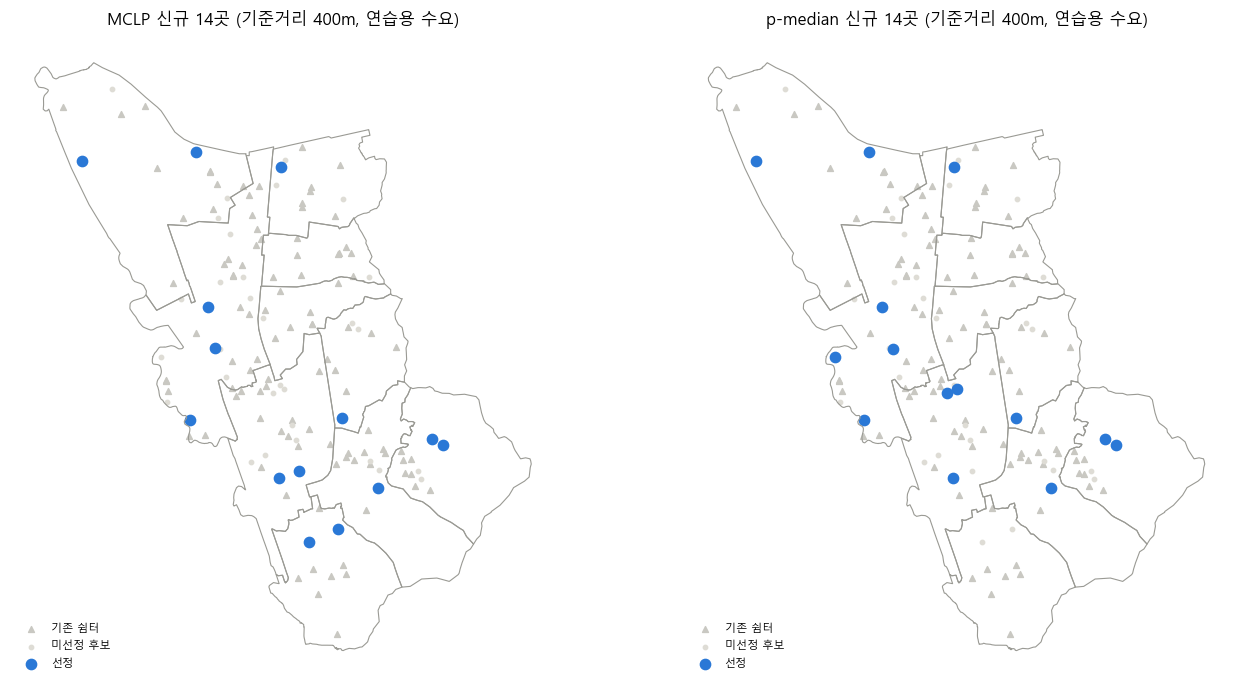

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (name, s_) in zip(axes, [("MCLP", sel_mclp), ("p-median", sel_pmed)]):
    adm_dong.boundary.plot(ax=ax, color="#9a9a94", linewidth=0.8)
    existing.plot(ax=ax, marker="^", markersize=18, color="#c9c8c2", label="기존 쉼터")
    candidate_clean.plot(ax=ax, markersize=10, color="#dedcd5", label="미선정 후보")
    candidate_clean.iloc[s_].plot(ax=ax, markersize=55, color="#2a78d6", label="선정")
    ax.set_title(f"{name} 신규 {len(s_)}곳 (기준거리 {S}m, 연습용 수요)")
    ax.set_axis_off()
    ax.legend(loc="lower left", fontsize=8, frameon=False)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "selected_map.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 12. 저장

In [15]:
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
sel.to_csv(OUTPUT_DIR / "selected_sites.csv", index=False, encoding="utf-8-sig")
sens_d.drop(columns="선정지").to_csv(OUTPUT_DIR / "sensitivity_distance.csv", index=False, encoding="utf-8-sig")
sens_p.to_csv(OUTPUT_DIR / "sensitivity_p.csv", index=False, encoding="utf-8-sig")
print("저장:", OUTPUT_DIR)

저장: C:\Users\USER\OneDrive\바탕 화면\공모전\shelter-location-mclp\DONGGEUN\output
